# sfig2 — Clinical Threshold Unlock Map (Supplementary Fig. S-2)

For each task (column) and required AUROC threshold (row): the
**first context length** where performance first meets that threshold.

Gray = never reached. Color = shorter context needed = easier to achieve.

**Data**: `analysis.csv`, k=all, split=test, Transformer head.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root ────────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils first (must come before explore to avoid shadowing utils.style)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))
# Explore panel functions — add utils/ subdir directly, not the parent package
_explore_utils = PAPER_FIGURES / "explore" / "notebooks" / "utils"
sys.path.insert(1, str(_explore_utils))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels
import panels_explore as xp   # from explore utils dir, no package conflict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS      = MAIN_TASKS   # change to include supp tasks if desired
HEAD       = "transformer"
THRESHOLDS = [0.70, 0.75, 0.80, 0.85, 0.90]

df = load_analysis("phase0_v3", split="test", k="all")
print("Loaded analysis.csv:", df.shape, "rows")
print("Heads:", sorted(df["head"].unique()))
print("Tasks:", sorted(df["task"].unique()))

Loaded analysis.csv: (126, 26) rows
Heads: ['lstm', 'mean_pool', 'transformer']
Tasks: ['age_class', 'apnea_binary', 'bmi_binary', 'depression_extreme_binary', 'osa_binary_apples_postqc', 'sex_binary', 'sleep_efficiency_binary']


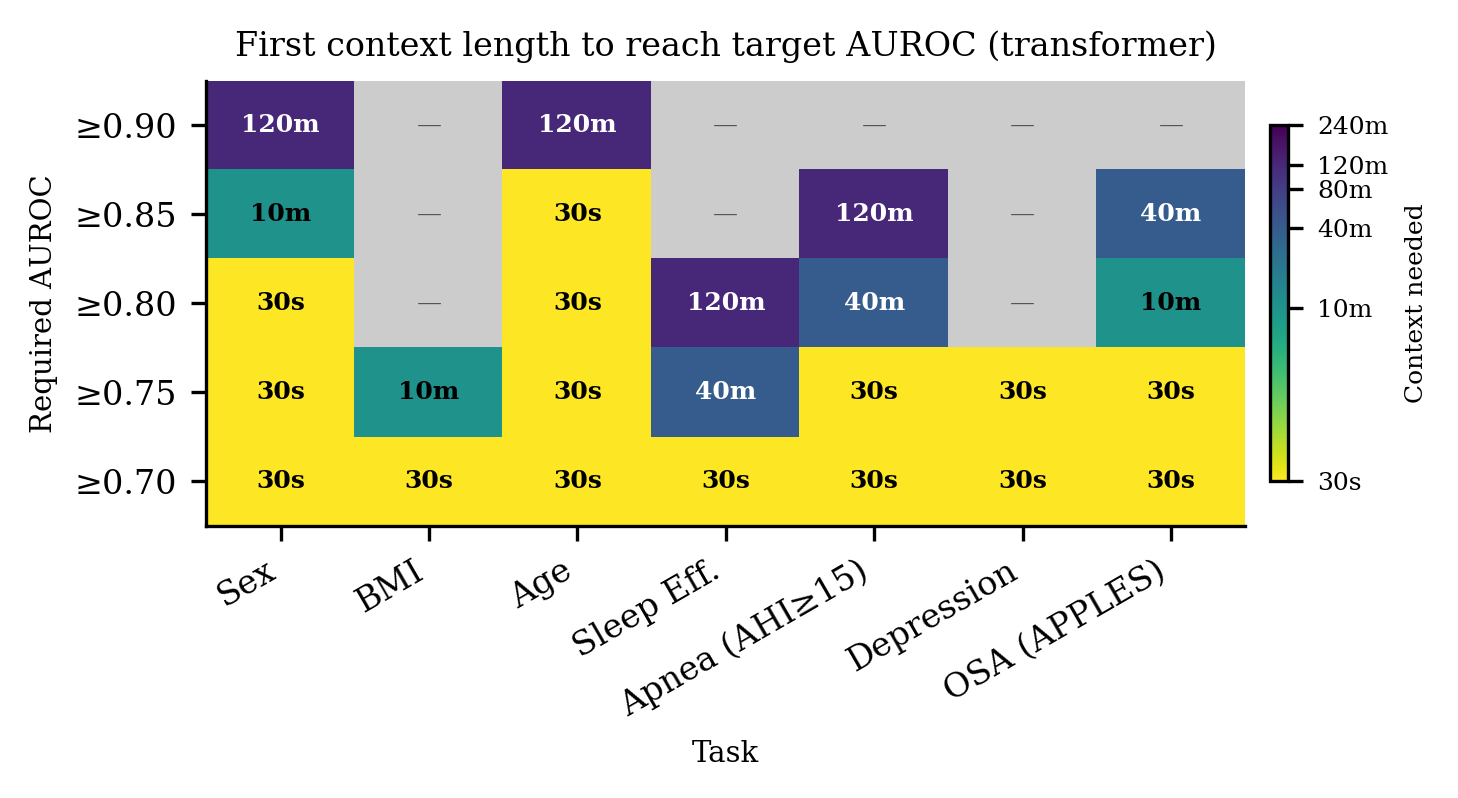

In [6]:
fig, ax = plt.subplots(figsize=(5, 2.7))

xp.threshold_unlock_heatmap(
    ax, df,
    tasks=ALL_TASKS,
    head=HEAD,
    thresholds=THRESHOLDS,
)
ax.set_title(
    f"First context length to reach target AUROC ({HEAD})",
    fontsize=8, pad=6,
)
fig.tight_layout()
plt.show()

In [7]:
# ── Run when figure looks good ────────────────────────────────────────────────
save_figure(fig, FINAL_OUT, "sfig2_threshold_unlock")
import shutil
shutil.copy(FINAL_OUT / "sfig2_threshold_unlock.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig2_threshold_unlock.pdf")
print("Saved + copied → TBME_submission/sfig2_threshold_unlock.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig2_threshold_unlock.pdf
Saved + copied → TBME_submission/sfig2_threshold_unlock.pdf
